In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzA2'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_moons, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)
torch.manual_seed(42)

print(f"✅ PyTorch {torch.__version__}")

✅ PyTorch 2.11.0+cpu


C:\Users\loich\AppData\Local\Temp\ipykernel_20576\1638218782.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


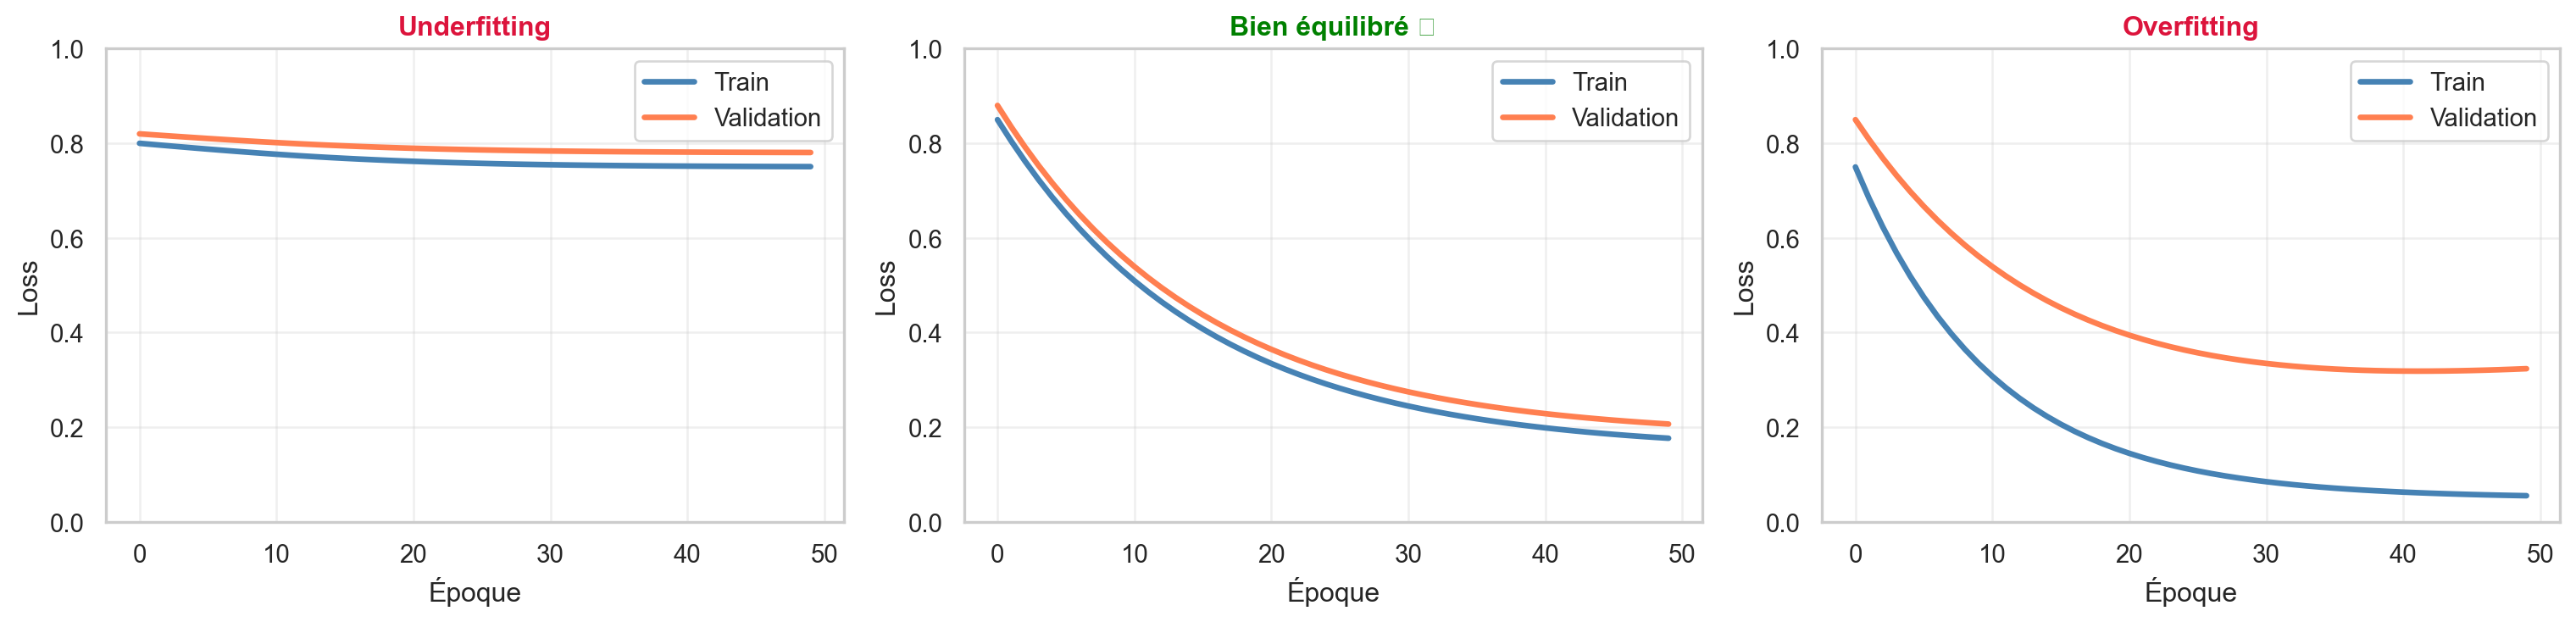

In [3]:
#| label: fig-under-over-right
#| fig-cap: 'Les 3 régimes : underfit, bien fit, overfit'

# Simulation des 3 régimes
epochs = np.arange(50)

# Underfit : loss élevée qui ne bouge pas
train_under = 0.8 - 0.05 * np.tanh(epochs / 20)
val_under = 0.82 - 0.04 * np.tanh(epochs / 20)

# Bien fit : les deux descendent ensemble
train_fit = 0.7 * np.exp(-epochs / 15) + 0.15
val_fit = 0.7 * np.exp(-epochs / 15) + 0.18

# Overfit : train descend, val remonte
train_over = 0.7 * np.exp(-epochs / 10) + 0.05
val_over = 0.7 * np.exp(-epochs / 15) + 0.15 + 0.003 * epochs

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, tr, va, titre, couleur in zip(
    axes,
    [train_under, train_fit, train_over],
    [val_under, val_fit, val_over],
    ["Underfitting", "Bien équilibré ✅", "Overfitting"],
    ["crimson", "green", "crimson"]
):
    ax.plot(epochs, tr, linewidth=2.5, label="Train", color="steelblue")
    ax.plot(epochs, va, linewidth=2.5, label="Validation", color="coral")
    ax.set_xlabel("Époque"); ax.set_ylabel("Loss")
    ax.set_title(titre, color=couleur, fontweight="bold")
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

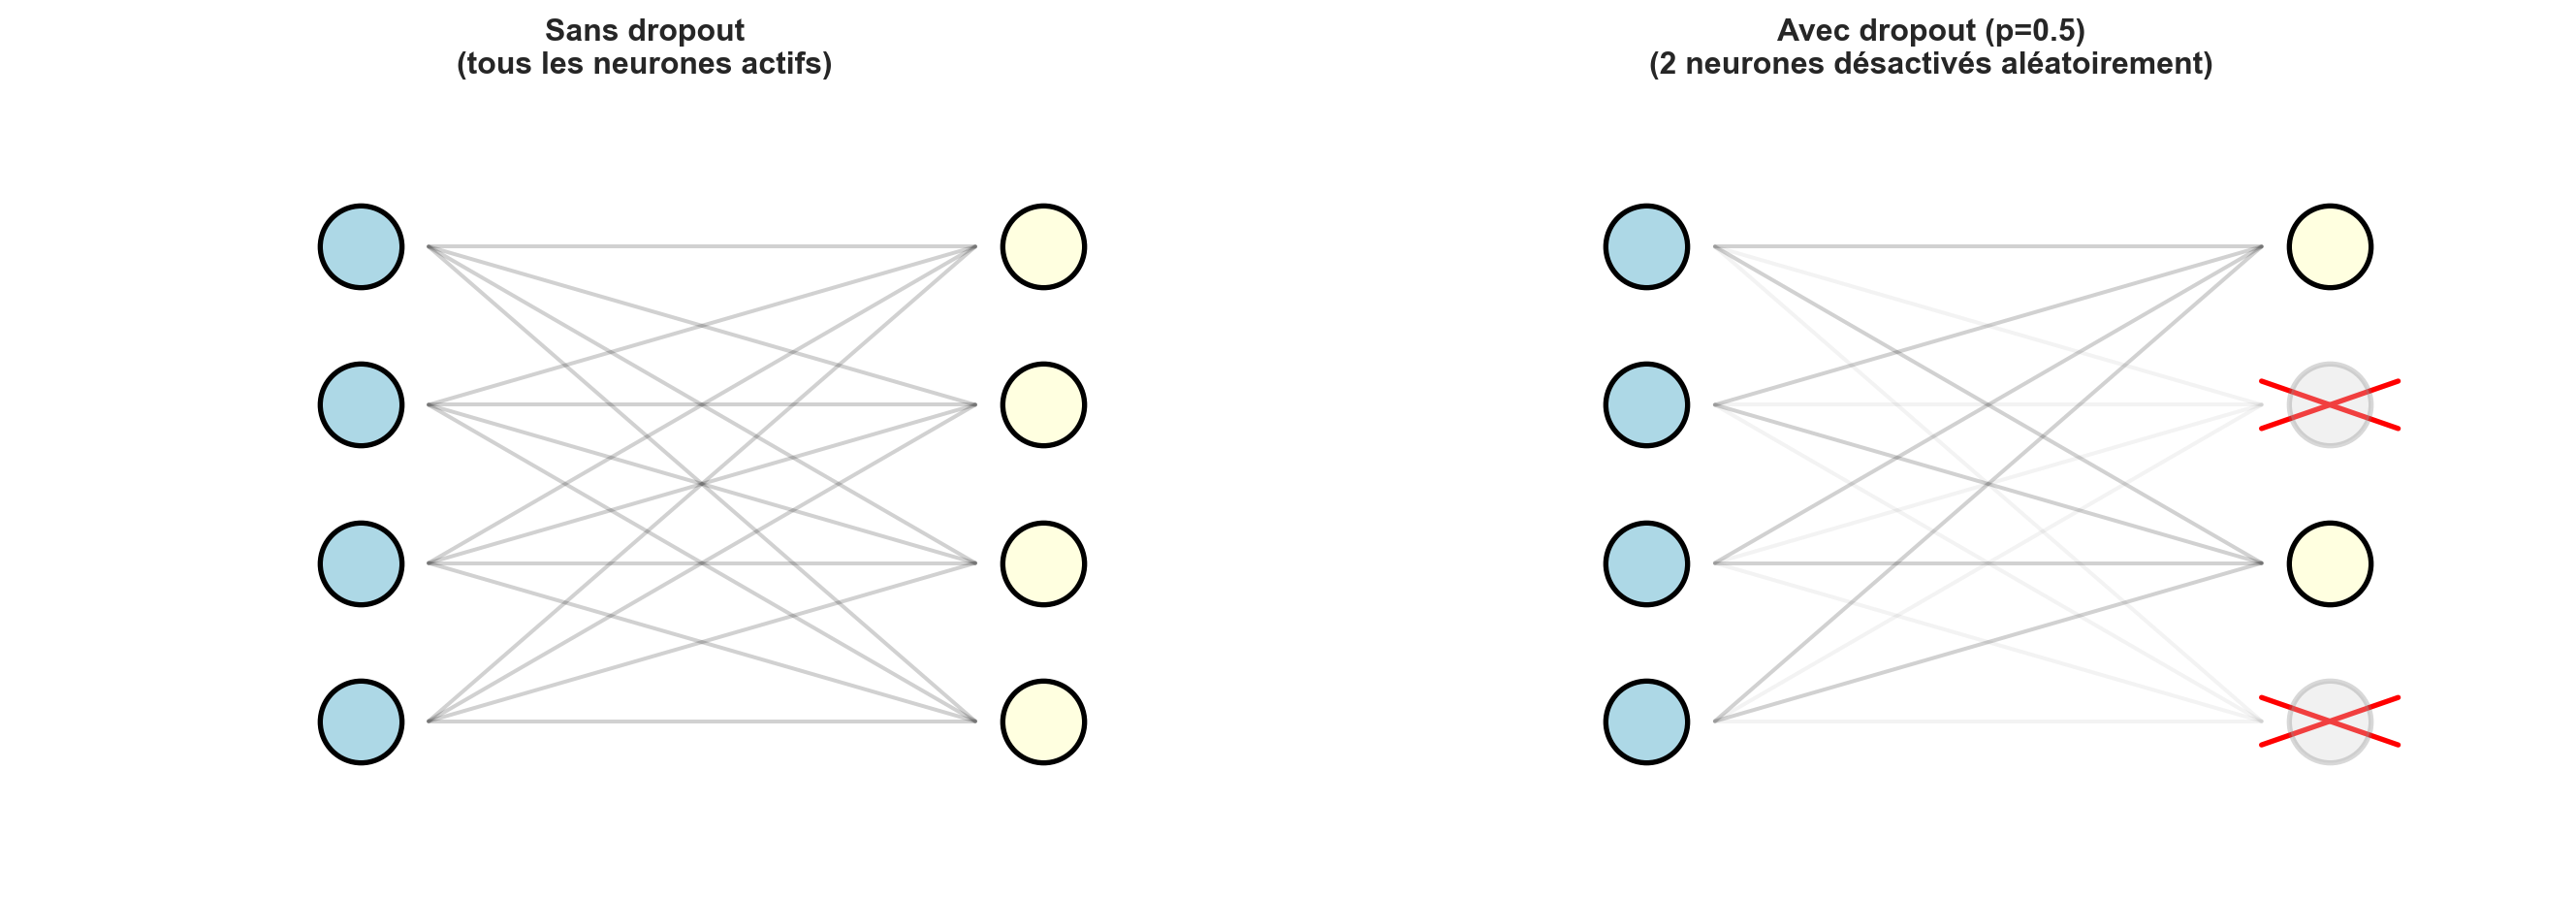

In [4]:
#| label: fig-dropout
#| fig-cap: 'Dropout : désactiver des neurones aléatoirement'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sans dropout : tous actifs
ax = axes[0]
ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 4.5)
ax.axis("off")
for y in [3.5, 2.5, 1.5, 0.5]:
    ax.scatter(1, y, s=1000, c="lightblue", edgecolor="black", linewidth=2, zorder=5)
    ax.scatter(4, y, s=1000, c="lightyellow", edgecolor="black", linewidth=2, zorder=5)
for y1 in [3.5, 2.5, 1.5, 0.5]:
    for y2 in [3.5, 2.5, 1.5, 0.5]:
        ax.plot([1.3, 3.7], [y1, y2], "k-", alpha=0.2)
ax.set_title("Sans dropout\n(tous les neurones actifs)", fontweight="bold", fontsize=12)

# Avec dropout : certains désactivés
ax = axes[1]
ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 4.5)
ax.axis("off")
np.random.seed(42)
actifs_l1 = [True, True, True, True]
actifs_l2 = [True, False, True, False]  # 2/4 désactivés
for y, actif in zip([3.5, 2.5, 1.5, 0.5], actifs_l1):
    color = "lightblue" if actif else "lightgray"
    edge = "black" if actif else "gray"
    ax.scatter(1, y, s=1000, c=color, edgecolor=edge, linewidth=2, zorder=5)
for y, actif in zip([3.5, 2.5, 1.5, 0.5], actifs_l2):
    color = "lightyellow" if actif else "lightgray"
    edge = "black" if actif else "gray"
    alpha_ = 1.0 if actif else 0.3
    ax.scatter(4, y, s=1000, c=color, edgecolor=edge, linewidth=2, zorder=5, alpha=alpha_)
    if not actif:
        ax.plot([3.7, 4.3], [y - 0.15, y + 0.15], "red", linewidth=2)
        ax.plot([3.7, 4.3], [y + 0.15, y - 0.15], "red", linewidth=2)

for y1 in [3.5, 2.5, 1.5, 0.5]:
    for y2, actif in zip([3.5, 2.5, 1.5, 0.5], actifs_l2):
        alpha_ = 0.2 if actif else 0.05
        ax.plot([1.3, 3.7], [y1, y2], "k-", alpha=alpha_)
ax.set_title("Avec dropout (p=0.5)\n(2 neurones désactivés aléatoirement)", fontweight="bold", fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
# MLP avec dropout
class MLPDropout(nn.Module):
    def __init__(self, n_input, n_hidden, n_output, dropout_p=0.3):
        super().__init__()
        self.fc1 = nn.Linear(n_input, n_hidden)
        self.drop1 = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.drop2 = nn.Dropout(dropout_p)
        self.fc3 = nn.Linear(n_hidden, n_output)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.drop1(x)
        x = torch.relu(self.fc2(x))
        x = self.drop2(x)
        x = self.fc3(x)
        return x

# Instancier
modele = MLPDropout(n_input=2, n_hidden=32, n_output=1, dropout_p=0.3)
print(modele)

MLPDropout(
  (fc1): Linear(in_features=2, out_features=32, bias=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


In [6]:
# Weight decay λ = 0.01
optimizer = optim.Adam(modele.parameters(), lr=0.01, weight_decay=0.01)
print("✅ Optimizer avec weight decay configuré")

✅ Optimizer avec weight decay configuré


In [7]:
# Implémentation simple
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None
    
    def step(self, val_loss, modele):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            # Sauvegarder l'état actuel
            self.best_state = {k: v.clone() for k, v in modele.state_dict().items()}
        else:
            self.counter += 1
        
        return self.counter >= self.patience
    
    def restore(self, modele):
        if self.best_state is not None:
            modele.load_state_dict(self.best_state)

print("✅ EarlyStopping défini")

✅ EarlyStopping défini


In [8]:
# Petit dataset avec du bruit
X, y = make_moons(n_samples=150, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

print(f"Train : {X_train.shape}, Test : {X_test.shape}")

Train : (105, 2), Test : (45, 2)


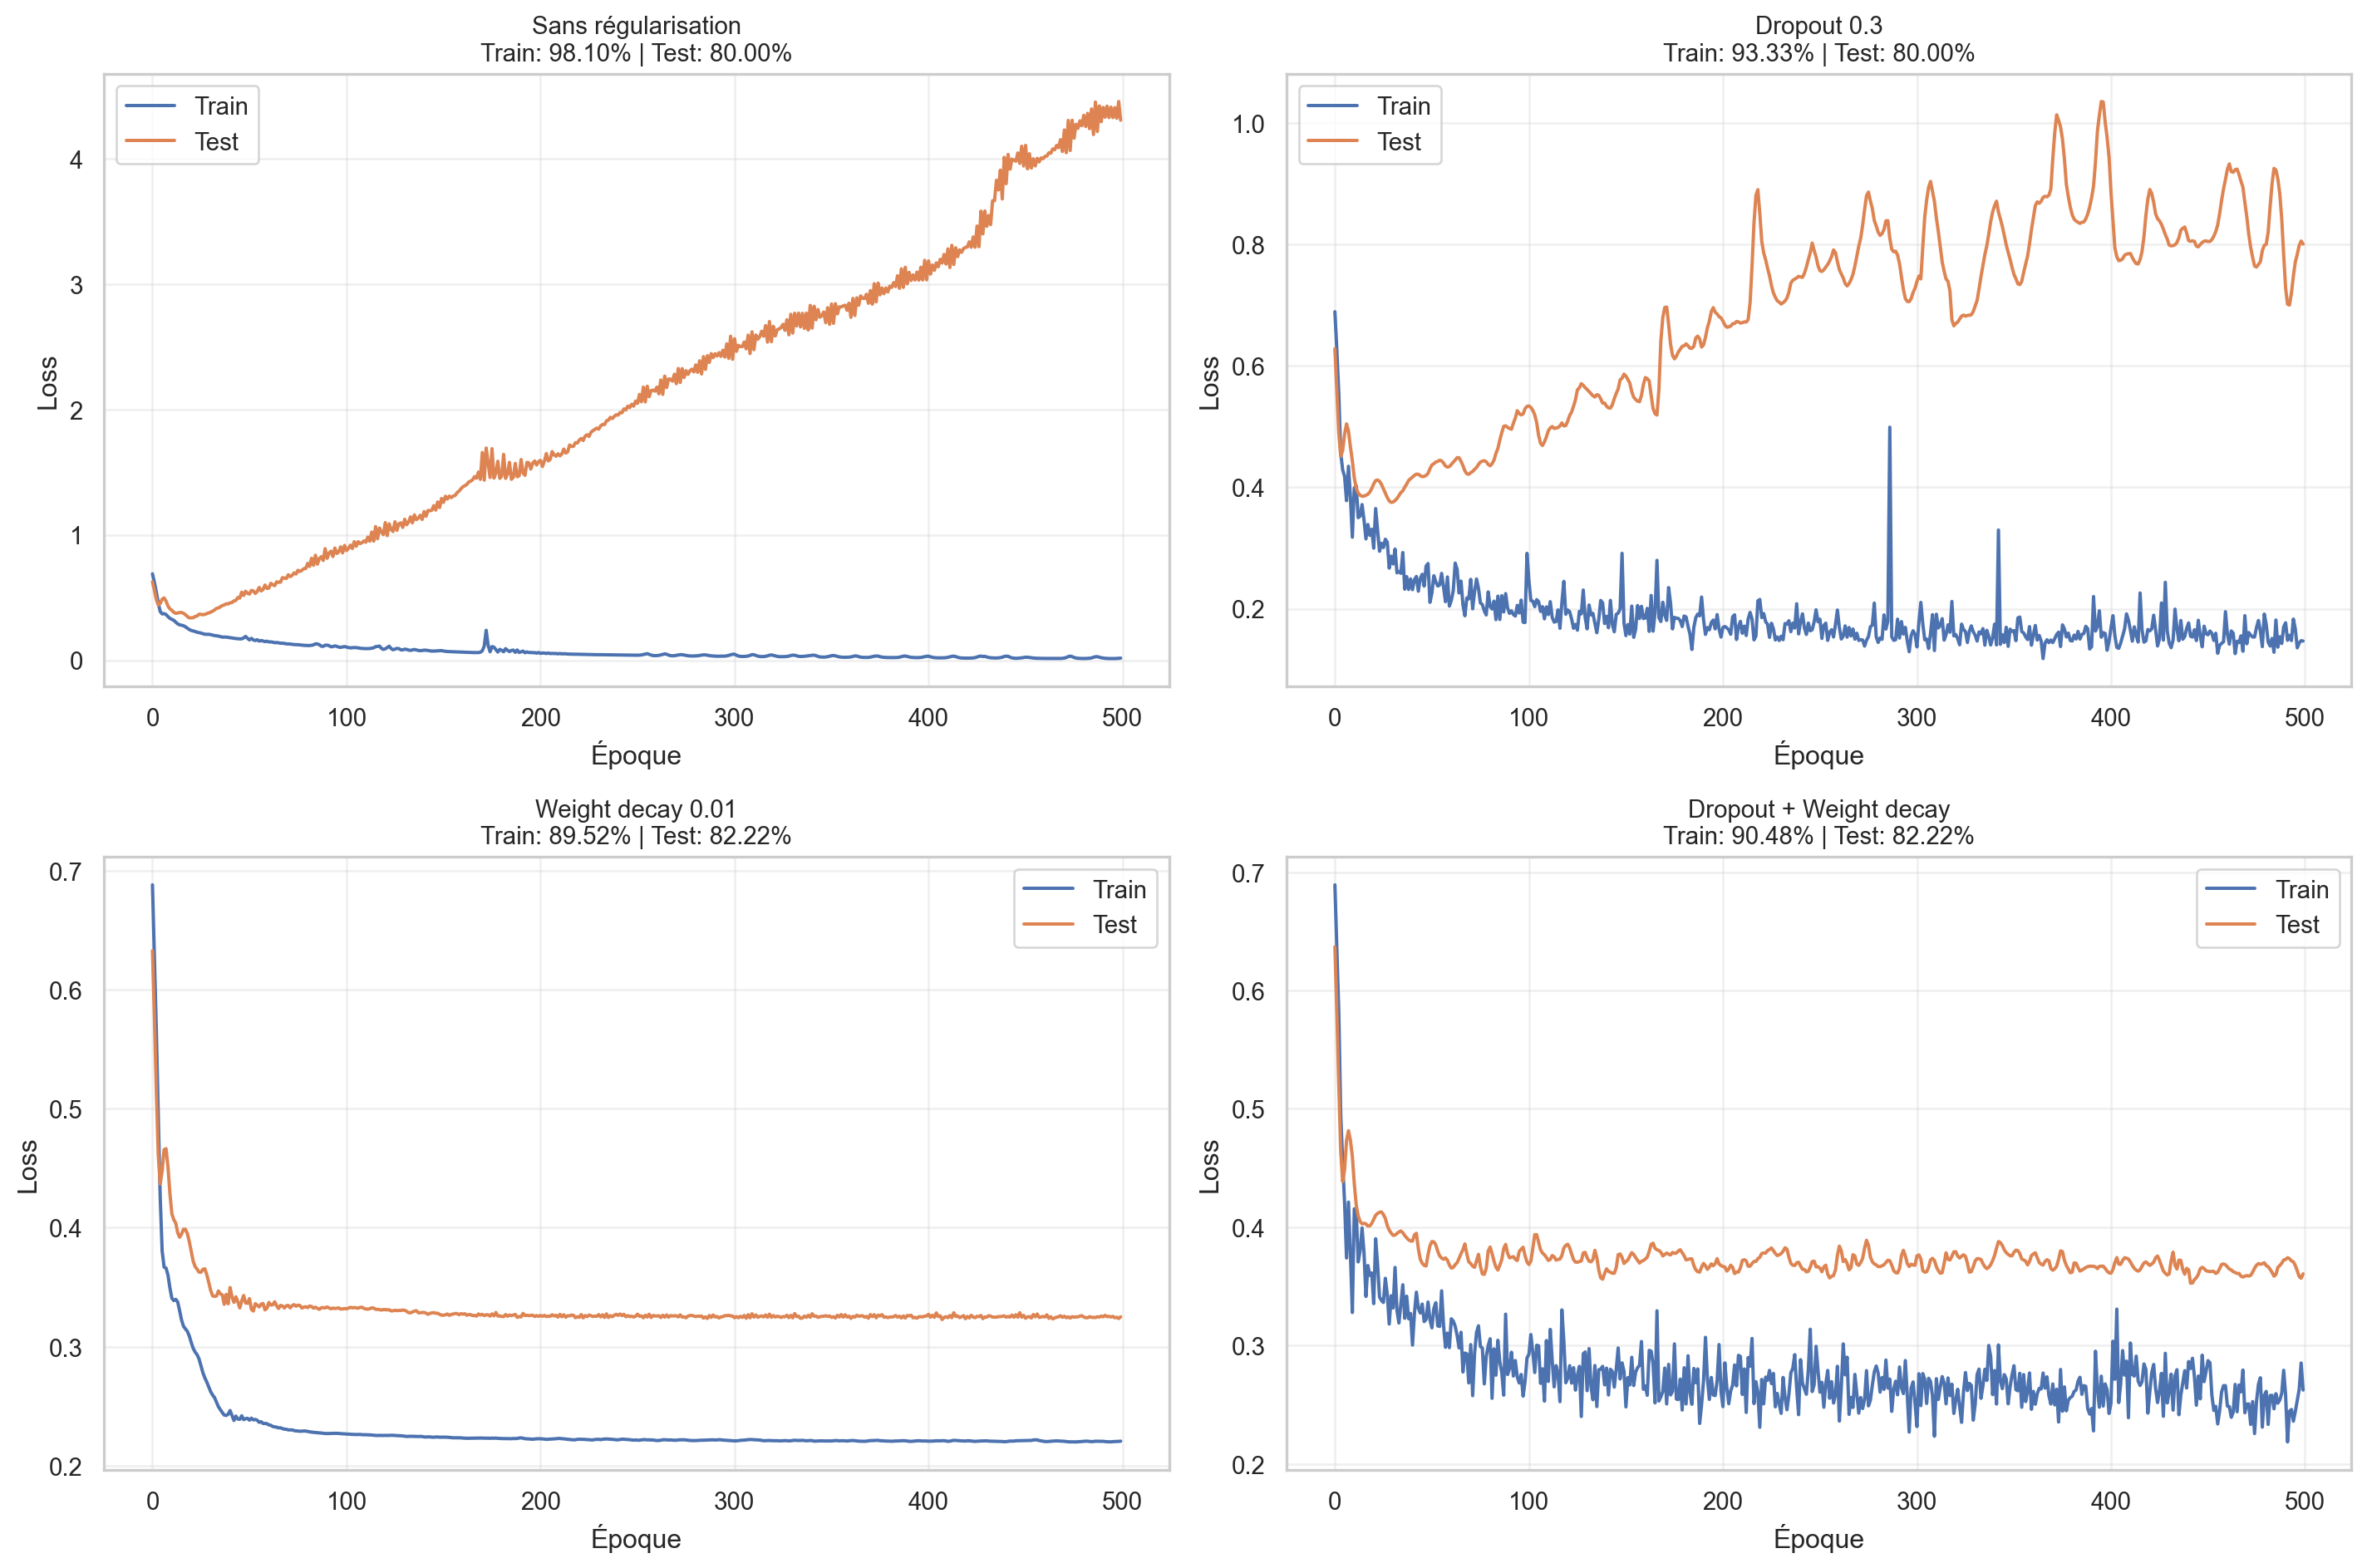


=== Récapitulatif ===
Sans régularisation            | Train 98.10% | Test 80.00% | Écart +18.10%
Dropout 0.3                    | Train 93.33% | Test 80.00% | Écart +13.33%
Weight decay 0.01              | Train 89.52% | Test 82.22% | Écart +7.30%
Dropout + Weight decay         | Train 90.48% | Test 82.22% | Écart +8.25%


In [9]:
# Modèle "gros" (propice à l'overfit)
class BigMLP(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 1)
        self.drop = nn.Dropout(dropout)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        x = torch.relu(self.fc2(x))
        x = self.drop(x)
        x = torch.relu(self.fc3(x))
        x = self.drop(x)
        return self.fc4(x)

def train_et_eval(dropout=0.0, weight_decay=0.0, n_epochs=500, seed=42):
    torch.manual_seed(seed)
    modele = BigMLP(dropout=dropout)
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(modele.parameters(), lr=0.01, weight_decay=weight_decay)
    
    train_losses, test_losses = [], []
    
    for epoch in range(n_epochs):
        # Train
        modele.train()
        logits = modele(X_train_t)
        loss = loss_fn(logits, y_train_t)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_losses.append(loss.item())
        
        # Eval
        modele.eval()
        with torch.no_grad():
            test_loss = loss_fn(modele(X_test_t), y_test_t).item()
            test_losses.append(test_loss)
    
    # Accuracies finales
    modele.eval()
    with torch.no_grad():
        acc_train = ((torch.sigmoid(modele(X_train_t)) >= 0.5).float() == y_train_t).float().mean().item()
        acc_test = ((torch.sigmoid(modele(X_test_t)) >= 0.5).float() == y_test_t).float().mean().item()
    
    return train_losses, test_losses, acc_train, acc_test

# Configs à tester
configs = {
    "Sans régularisation": (0.0, 0.0),
    "Dropout 0.3": (0.3, 0.0),
    "Weight decay 0.01": (0.0, 0.01),
    "Dropout + Weight decay": (0.3, 0.01),
}

resultats = {}
for nom, (drop, wd) in configs.items():
    tr, te, acc_tr, acc_te = train_et_eval(dropout=drop, weight_decay=wd)
    resultats[nom] = {"train_loss": tr, "test_loss": te,
                      "acc_train": acc_tr, "acc_test": acc_te}

# Affichage
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (nom, res) in zip(axes.flat, resultats.items()):
    ax.plot(res["train_loss"], linewidth=1.5, label="Train")
    ax.plot(res["test_loss"], linewidth=1.5, label="Test")
    ax.set_title(f"{nom}\nTrain: {res['acc_train']:.2%} | Test: {res['acc_test']:.2%}", fontsize=11)
    ax.set_xlabel("Époque"); ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Récap
print("\n=== Récapitulatif ===")
for nom, res in resultats.items():
    ecart = res['acc_train'] - res['acc_test']
    print(f"{nom:30s} | Train {res['acc_train']:.2%} | Test {res['acc_test']:.2%} | Écart {ecart:+.2%}")

In [10]:
#| eval: false
# TODO: Exercice 1

Arrêt à l'époque : 49
Meilleure val_loss : 0.3374


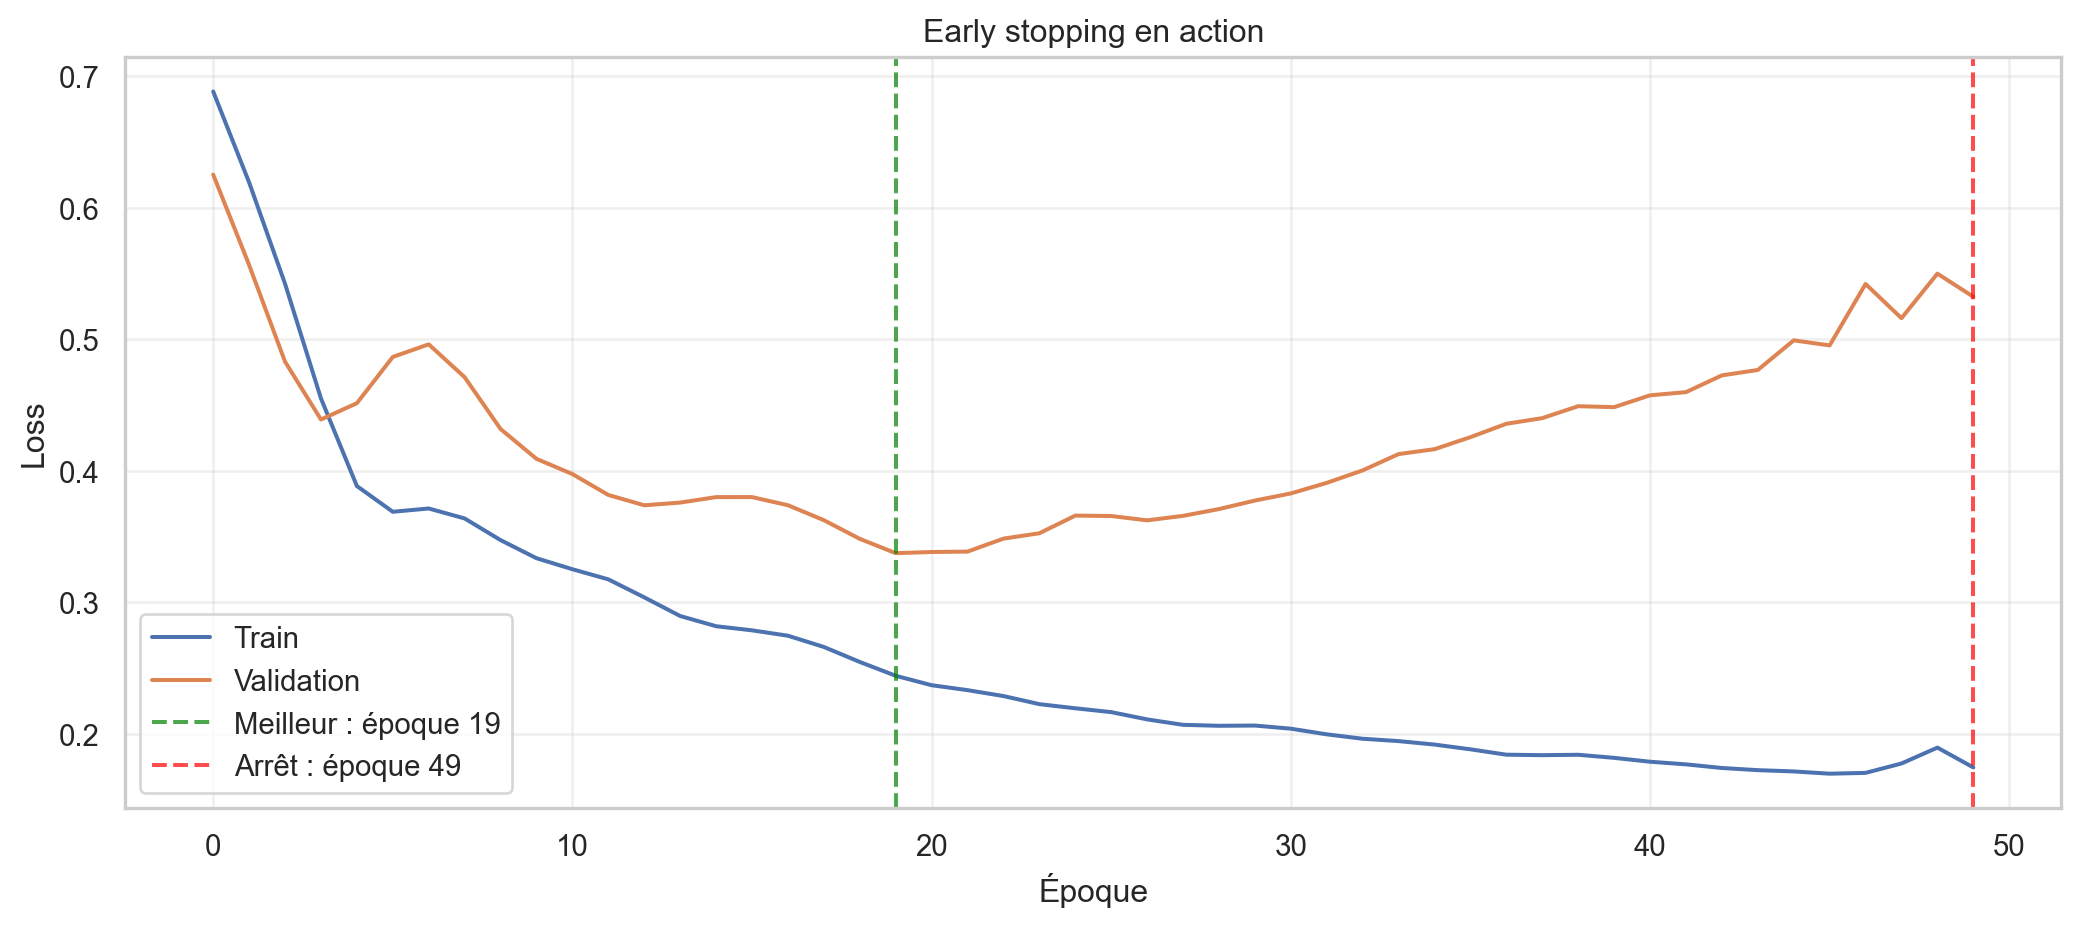

Accuracy test après restauration : 0.822


In [11]:
torch.manual_seed(42)
modele = BigMLP(dropout=0.0)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(modele.parameters(), lr=0.01)
early_stop = EarlyStopping(patience=30)

train_losses, val_losses = [], []
epoque_arret = None

for epoch in range(500):
    # Train
    modele.train()
    logits = modele(X_train_t)
    loss = loss_fn(logits, y_train_t)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    train_losses.append(loss.item())
    
    # Val
    modele.eval()
    with torch.no_grad():
        val_loss = loss_fn(modele(X_test_t), y_test_t).item()
    val_losses.append(val_loss)
    
    # Early stopping
    if early_stop.step(val_loss, modele):
        epoque_arret = epoch
        break

# Restaurer le meilleur modèle
early_stop.restore(modele)

print(f"Arrêt à l'époque : {epoque_arret if epoque_arret else 'fin'}")
print(f"Meilleure val_loss : {early_stop.best_loss:.4f}")

# Affichage
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train_losses, linewidth=1.5, label="Train")
ax.plot(val_losses, linewidth=1.5, label="Validation")
best_epoch = val_losses.index(min(val_losses))
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.7, label=f"Meilleur : époque {best_epoch}")
if epoque_arret:
    ax.axvline(epoque_arret, color="red", linestyle="--", alpha=0.7, label=f"Arrêt : époque {epoque_arret}")
ax.set_xlabel("Époque"); ax.set_ylabel("Loss")
ax.set_title("Early stopping en action")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Accuracy finale
modele.eval()
with torch.no_grad():
    acc_test = ((torch.sigmoid(modele(X_test_t)) >= 0.5).float() == y_test_t).float().mean().item()
print(f"Accuracy test après restauration : {acc_test:.3f}")

In [12]:
# SGD basique
opt_sgd = optim.SGD(modele.parameters(), lr=0.01)

# SGD + momentum (très populaire pour CV)
opt_sgd_mom = optim.SGD(modele.parameters(), lr=0.01, momentum=0.9)

# Adam (le défaut)
opt_adam = optim.Adam(modele.parameters(), lr=0.001)

# AdamW (Adam corrigé)
opt_adamw = optim.AdamW(modele.parameters(), lr=0.001, weight_decay=0.01)

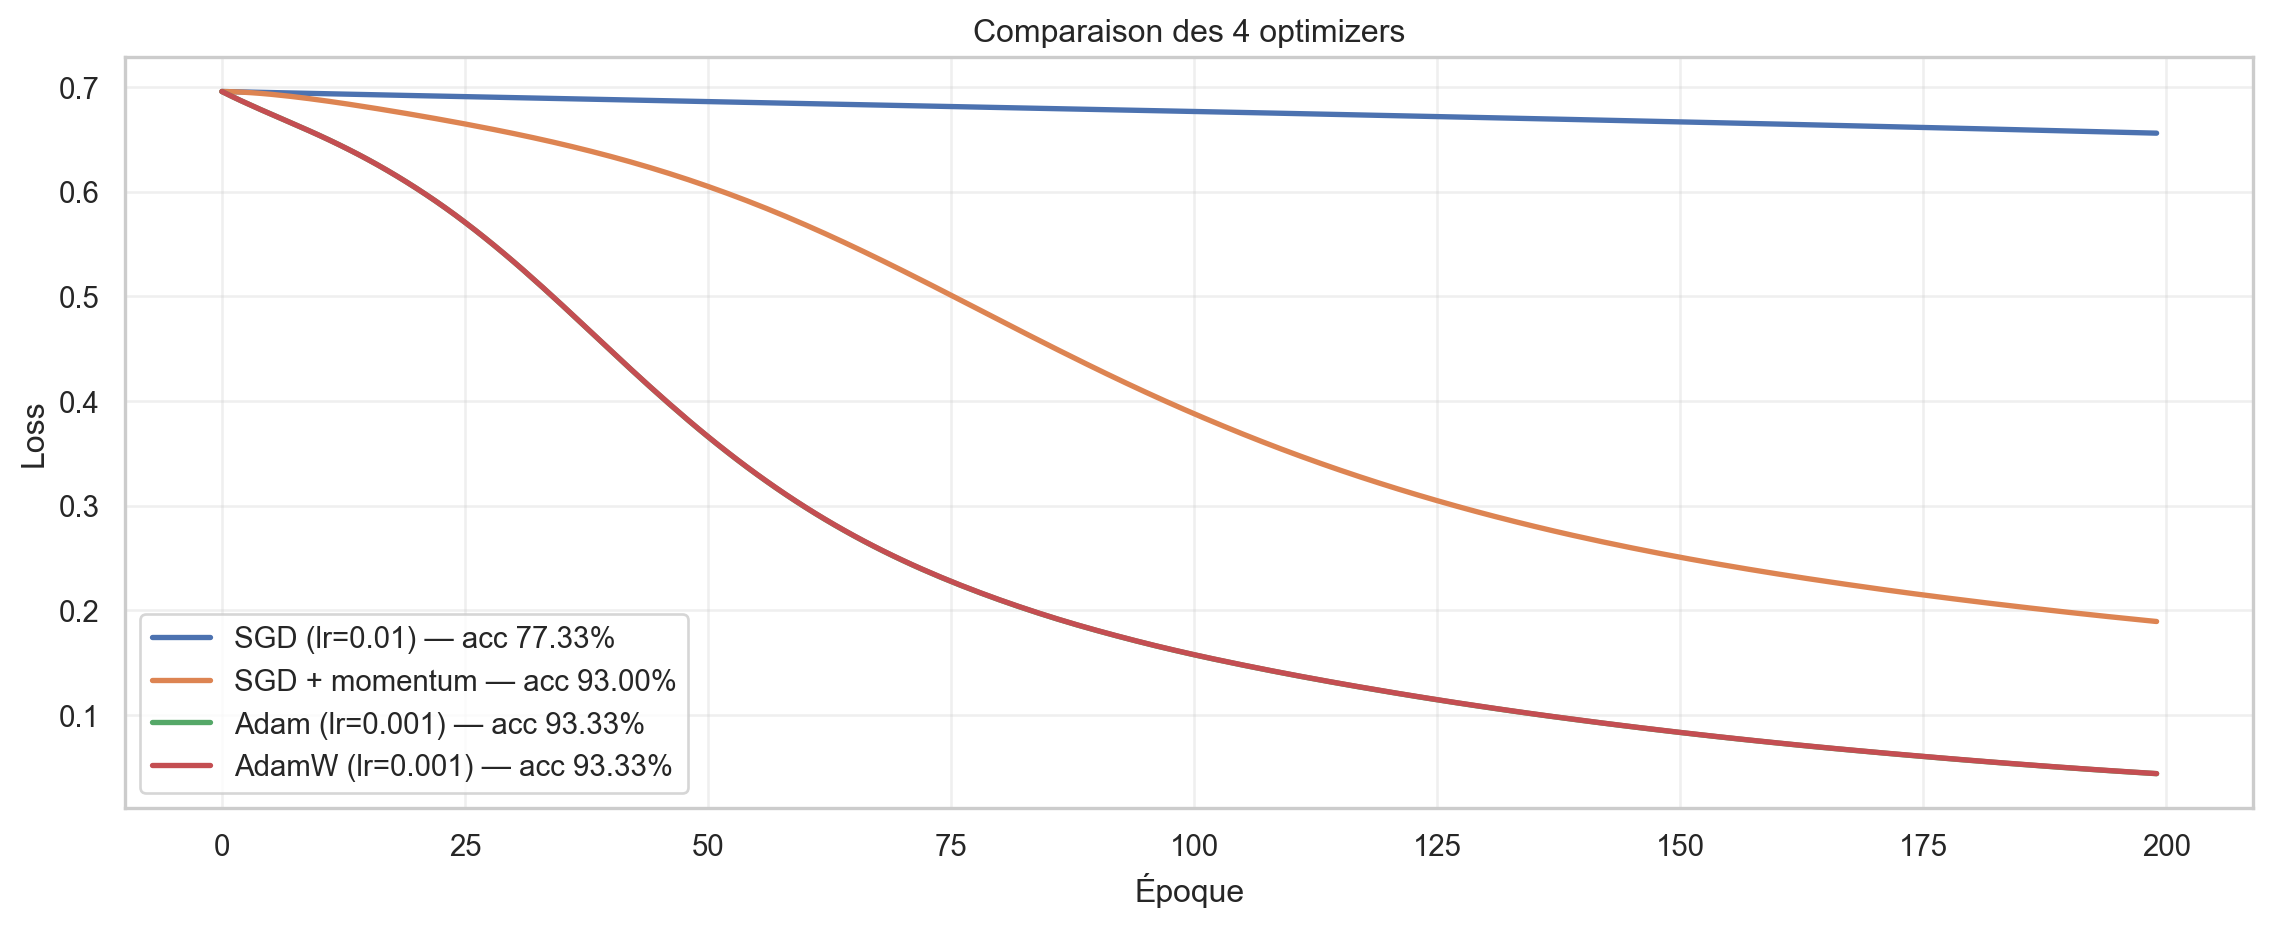

In [13]:
# Dataset plus complexe
X_big, y_big = make_classification(
    n_samples=1000, n_features=20, n_informative=10,
    n_redundant=5, n_classes=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X_big, y_big, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

class MLPBig(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(20, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

def train_with_optimizer(optimizer_cls, **kwargs):
    torch.manual_seed(42)
    modele = MLPBig()
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optimizer_cls(modele.parameters(), **kwargs)
    
    losses = []
    for epoch in range(200):
        logits = modele(X_train_t)
        loss = loss_fn(logits, y_train_t)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
    
    modele.eval()
    with torch.no_grad():
        acc = ((torch.sigmoid(modele(X_test_t)) >= 0.5).float() == y_test_t).float().mean().item()
    
    return losses, acc

# Test des 4 optimizers
optimizers = {
    "SGD (lr=0.01)": (optim.SGD, {"lr": 0.01}),
    "SGD + momentum": (optim.SGD, {"lr": 0.01, "momentum": 0.9}),
    "Adam (lr=0.001)": (optim.Adam, {"lr": 0.001}),
    "AdamW (lr=0.001)": (optim.AdamW, {"lr": 0.001, "weight_decay": 0.01}),
}

resultats = {}
for nom, (cls, kwargs) in optimizers.items():
    losses, acc = train_with_optimizer(cls, **kwargs)
    resultats[nom] = {"losses": losses, "acc": acc}

# Affichage
fig, ax = plt.subplots(figsize=(12, 5))
for nom, res in resultats.items():
    ax.plot(res["losses"], linewidth=2, label=f"{nom} — acc {res['acc']:.2%}")
ax.set_xlabel("Époque"); ax.set_ylabel("Loss")
ax.set_title("Comparaison des 4 optimizers")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

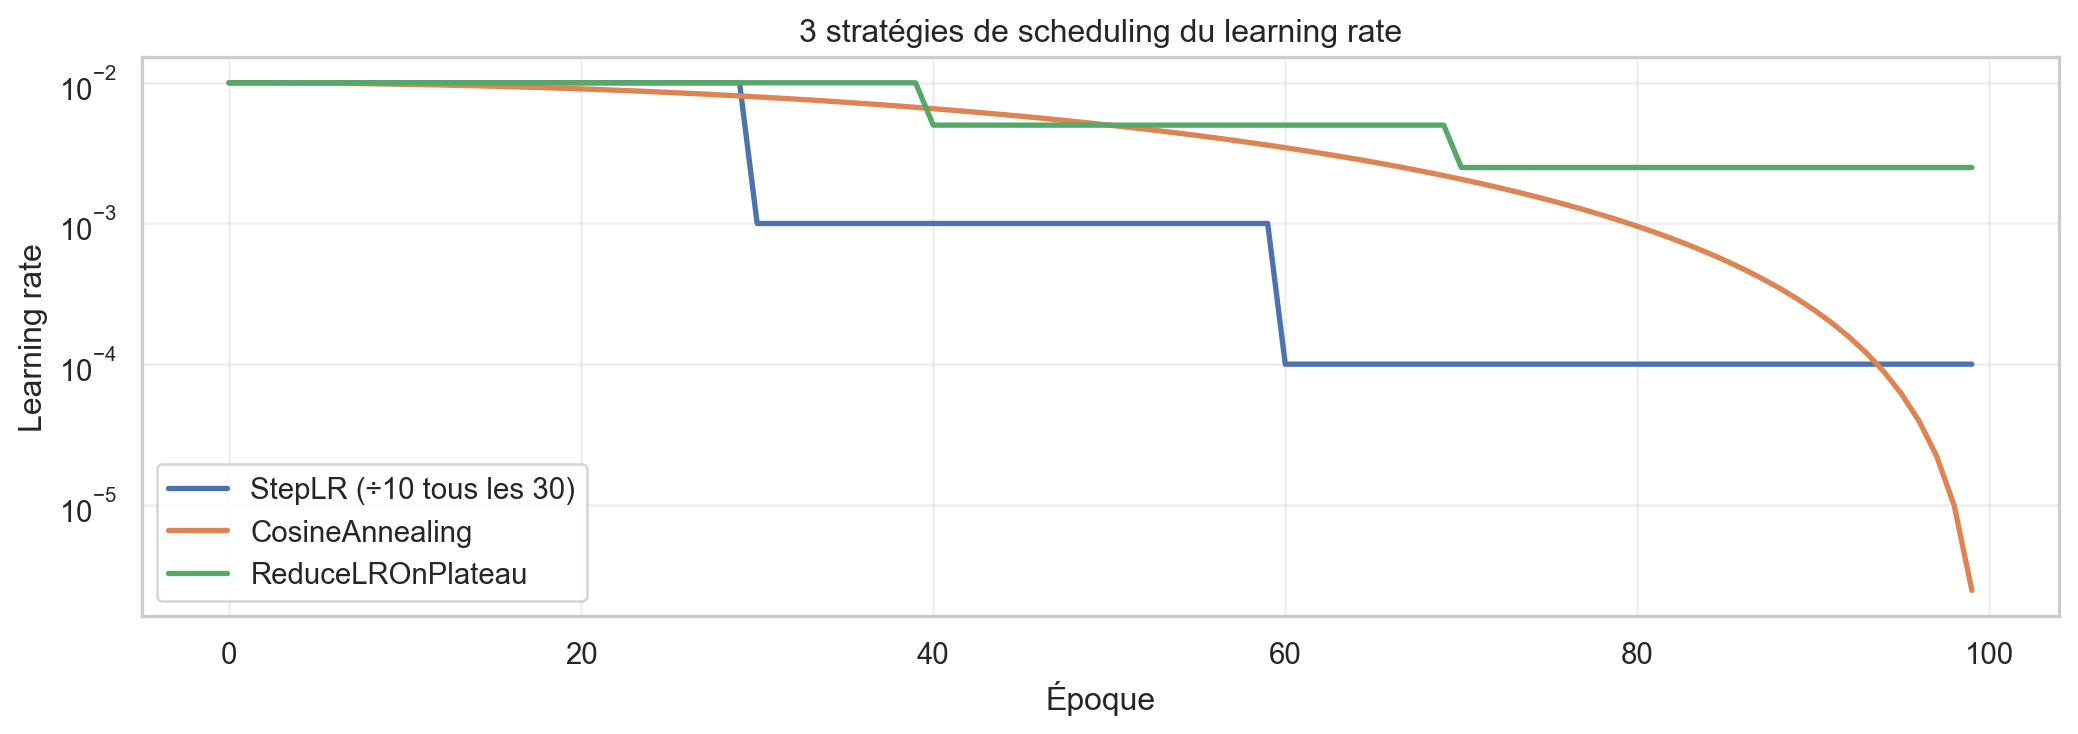

In [14]:
#| label: fig-schedulers
#| fig-cap: Les 3 schedulers courants

epochs = np.arange(100)
lr_init = 0.01

# Step decay : divise par 10 tous les 30 epochs
lr_step = np.where(epochs < 30, lr_init,
                    np.where(epochs < 60, lr_init * 0.1, lr_init * 0.01))

# Cosine annealing : décroissance en cosinus
lr_cosine = lr_init * 0.5 * (1 + np.cos(np.pi * epochs / 100))

# Reduce on plateau : simulation (baisse quand la val_loss stagne)
lr_plateau = np.copy(epochs).astype(float)
lr_plateau[:] = lr_init
lr_plateau[40:] = lr_init * 0.5
lr_plateau[70:] = lr_init * 0.25

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(epochs, lr_step, linewidth=2, label="StepLR (÷10 tous les 30)")
ax.plot(epochs, lr_cosine, linewidth=2, label="CosineAnnealing")
ax.plot(epochs, lr_plateau, linewidth=2, label="ReduceLROnPlateau")
ax.set_xlabel("Époque"); ax.set_ylabel("Learning rate")
ax.set_title("3 stratégies de scheduling du learning rate")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

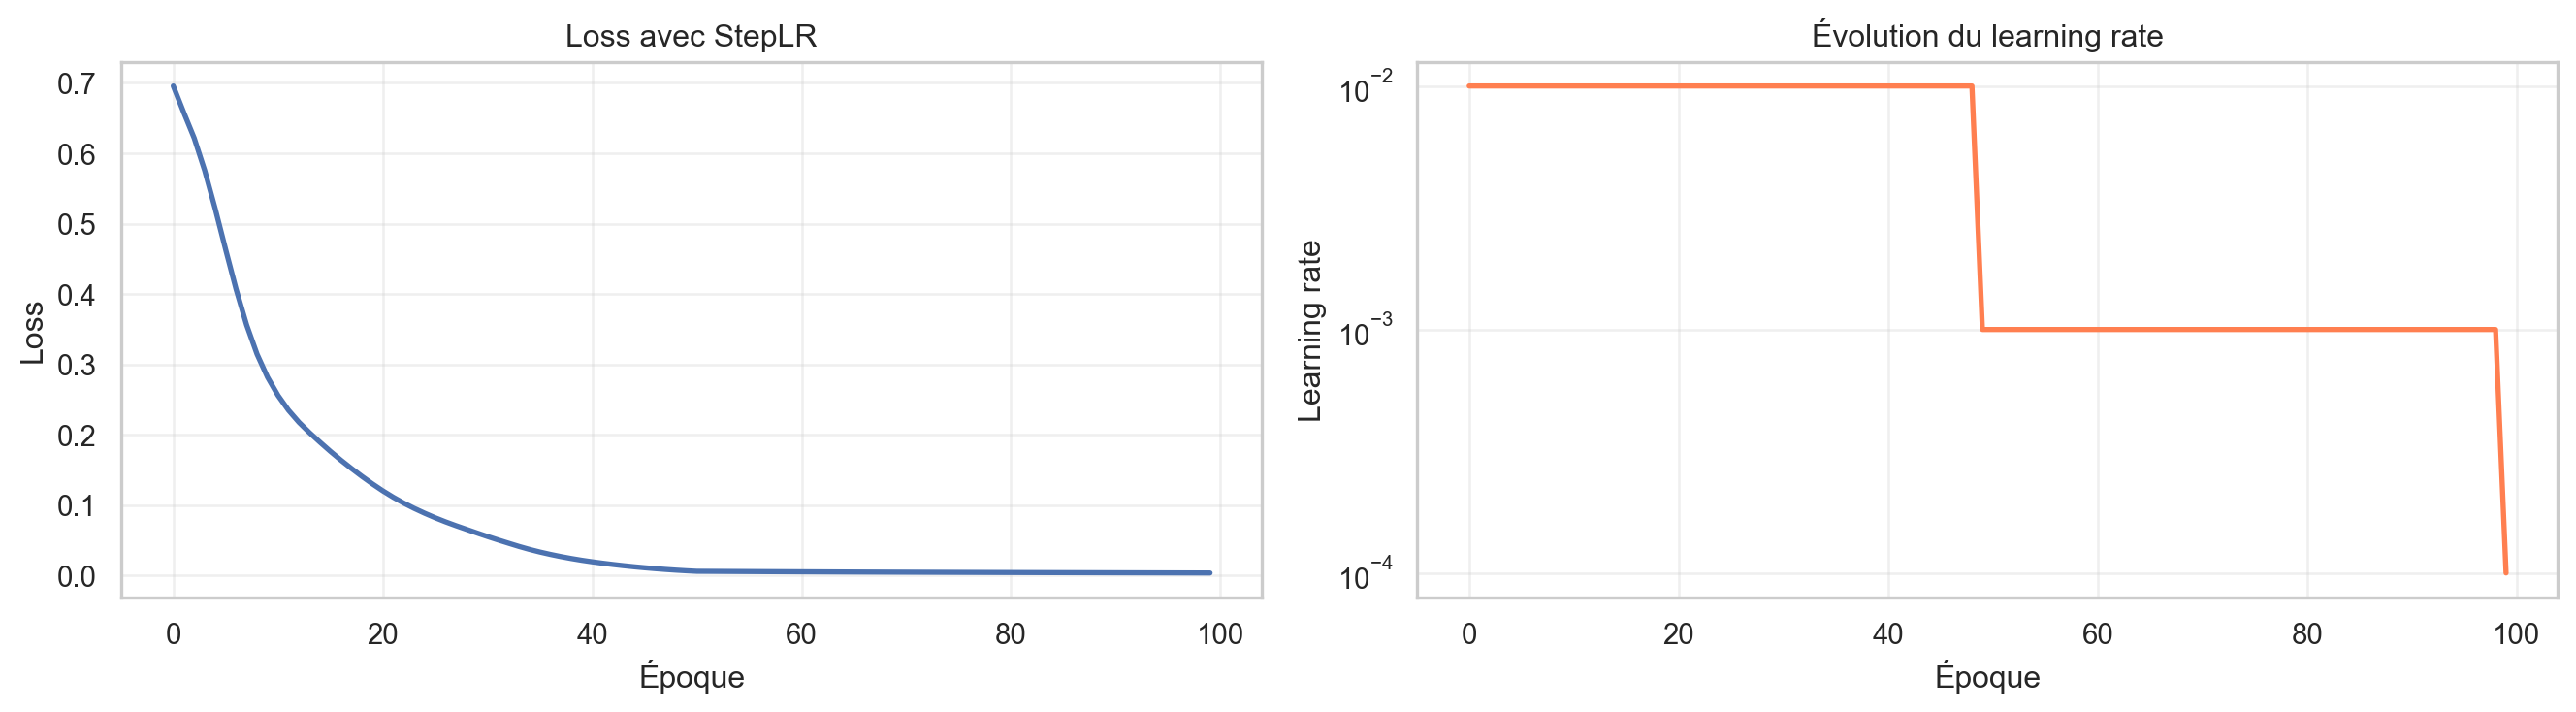

In [15]:
# Modèle + optimizer
torch.manual_seed(42)
modele = MLPBig()
optimizer = optim.Adam(modele.parameters(), lr=0.01)

# Scheduler : divise lr par 10 tous les 50 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

loss_fn = nn.BCEWithLogitsLoss()
losses, lrs = [], []

for epoch in range(100):
    logits = modele(X_train_t)
    loss = loss_fn(logits, y_train_t)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    
    # IMPORTANT : appeler scheduler.step() après optimizer.step()
    scheduler.step()
    
    losses.append(loss.item())
    lrs.append(optimizer.param_groups[0]["lr"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses, linewidth=2)
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss avec StepLR")
axes[0].grid(True, alpha=0.3)

axes[1].plot(lrs, linewidth=2, color="coral")
axes[1].set_xlabel("Époque"); axes[1].set_ylabel("Learning rate")
axes[1].set_title("Évolution du learning rate")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
#| eval: false
# TODO: Exercice 2

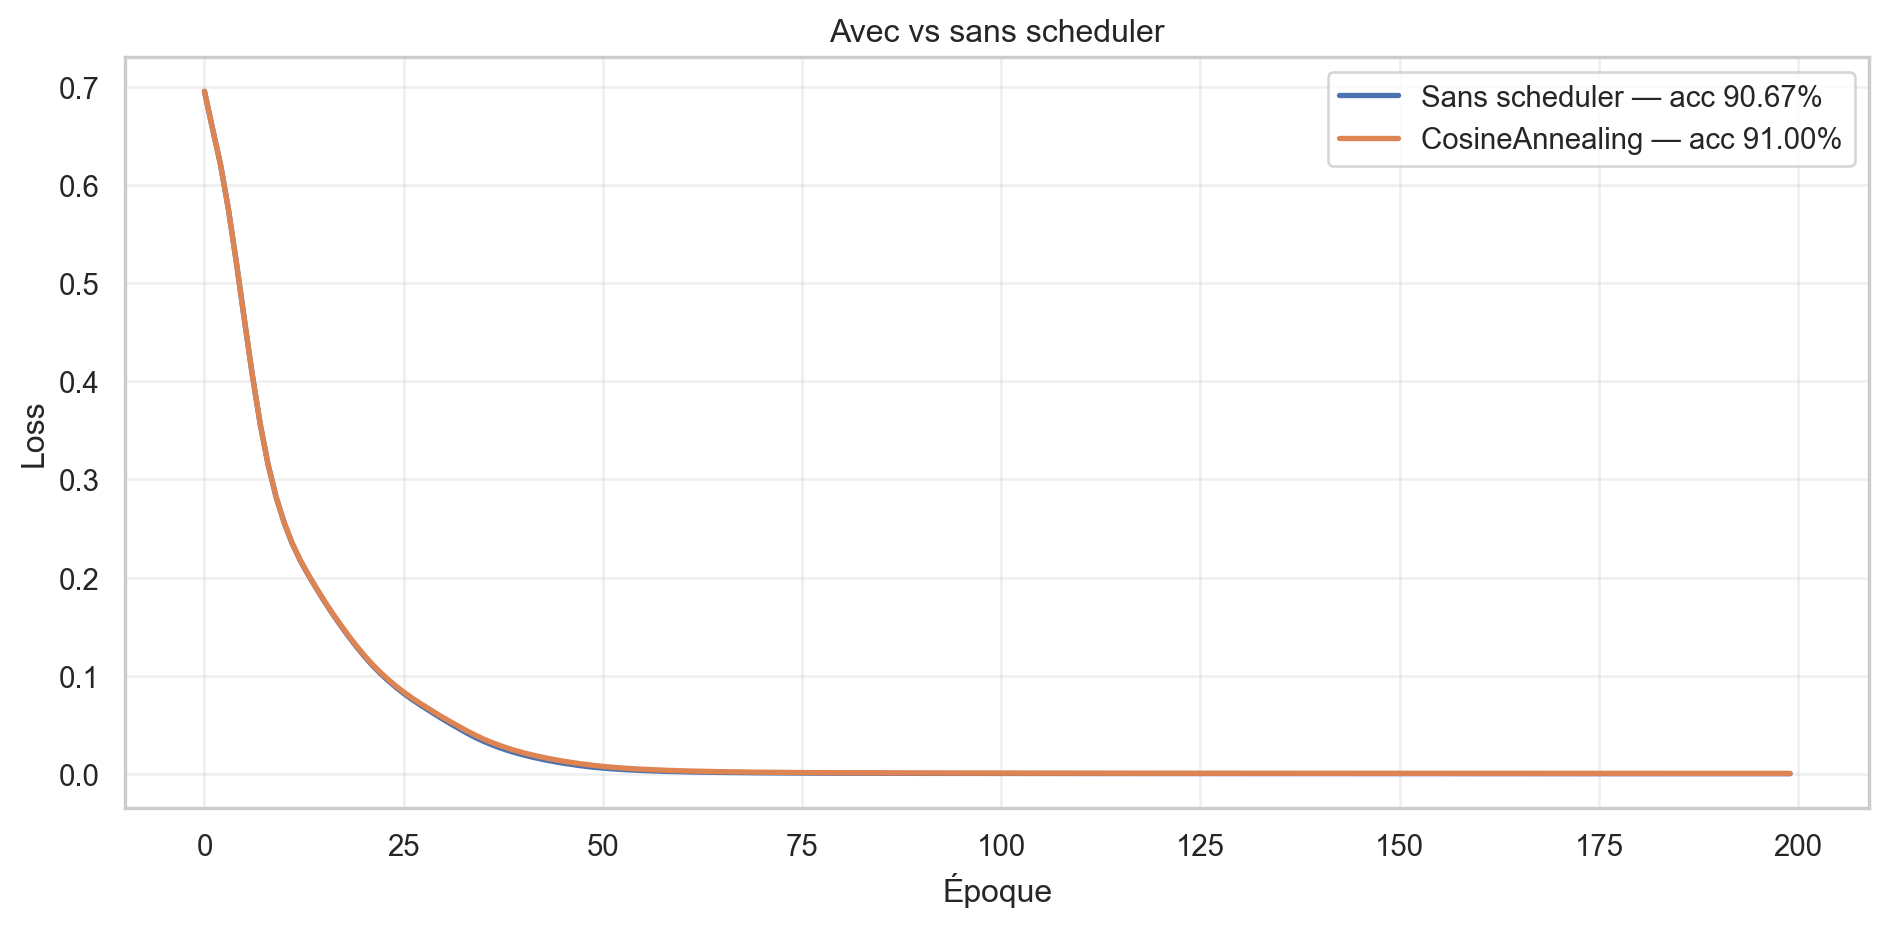

In [17]:
def train_avec_scheduler(use_scheduler=False):
    torch.manual_seed(42)
    modele = MLPBig()
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(modele.parameters(), lr=0.01)
    scheduler = (optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)
                 if use_scheduler else None)
    
    losses = []
    for epoch in range(200):
        logits = modele(X_train_t)
        loss = loss_fn(logits, y_train_t)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        if scheduler is not None:
            scheduler.step()
        losses.append(loss.item())
    
    modele.eval()
    with torch.no_grad():
        acc = ((torch.sigmoid(modele(X_test_t)) >= 0.5).float() == y_test_t).float().mean().item()
    return losses, acc

losses_sans, acc_sans = train_avec_scheduler(use_scheduler=False)
losses_avec, acc_avec = train_avec_scheduler(use_scheduler=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses_sans, linewidth=2, label=f"Sans scheduler — acc {acc_sans:.2%}")
ax.plot(losses_avec, linewidth=2, label=f"CosineAnnealing — acc {acc_avec:.2%}")
ax.set_xlabel("Époque"); ax.set_ylabel("Loss")
ax.set_title("Avec vs sans scheduler")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
class MLPBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(20, 64)
        self.bn1 = nn.BatchNorm1d(64)  # 1d car entrées 1D
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)       # normalise
        x = torch.relu(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        return self.fc3(x)

print("MLP avec BatchNorm défini")

MLP avec BatchNorm défini


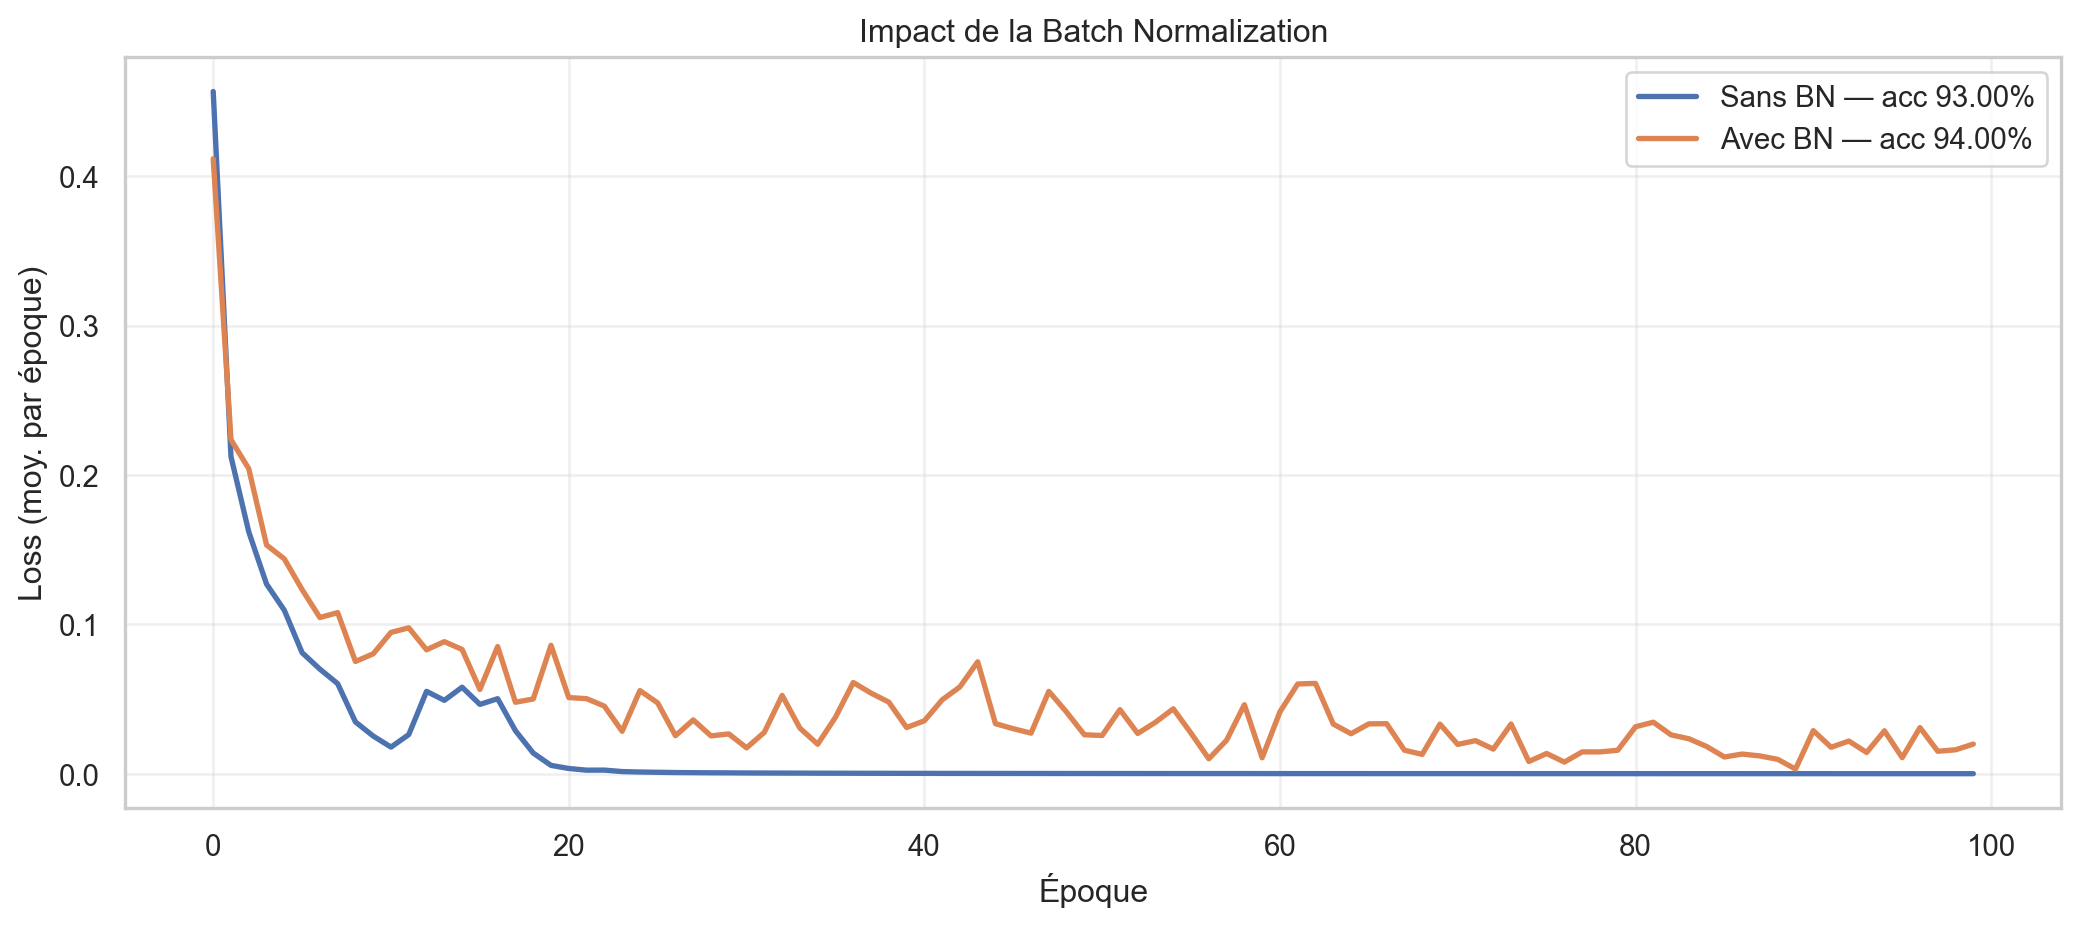

In [19]:
# DataLoader pour mini-batchs (BN a besoin de batchs > 1)
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

def train_model(model_cls, n_epochs=100, lr=0.01):
    torch.manual_seed(42)
    modele = model_cls()
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(modele.parameters(), lr=lr)
    
    losses = []
    for epoch in range(n_epochs):
        modele.train()
        epoch_losses = []
        for Xb, yb in train_loader:
            logits = modele(Xb)
            loss = loss_fn(logits, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_losses.append(loss.item())
        losses.append(np.mean(epoch_losses))
    
    modele.eval()
    with torch.no_grad():
        acc = ((torch.sigmoid(modele(X_test_t)) >= 0.5).float() == y_test_t).float().mean().item()
    return losses, acc

# Avec et sans BN
losses_sans, acc_sans = train_model(MLPBig)
losses_avec, acc_avec = train_model(MLPBN)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(losses_sans, linewidth=2, label=f"Sans BN — acc {acc_sans:.2%}")
ax.plot(losses_avec, linewidth=2, label=f"Avec BN — acc {acc_avec:.2%}")
ax.set_xlabel("Époque"); ax.set_ylabel("Loss (moy. par époque)")
ax.set_title("Impact de la Batch Normalization")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Initialisation He pour tous les Linear
def init_he(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)

modele = MLPBig()
modele.apply(init_he)
print("Initialisation He appliquée")

# Vérifier
for nom, p in modele.named_parameters():
    print(f"{nom:15s} : mean {p.mean().item():+.3f}, std {p.std().item():.3f}")

Initialisation He appliquée
fc1.weight      : mean -0.007, std 0.316
fc1.bias        : mean +0.000, std 0.000
fc2.weight      : mean -0.000, std 0.176
fc2.bias        : mean +0.000, std 0.000
fc3.weight      : mean -0.042, std 0.198
fc3.bias        : mean +0.000, std nan


C:\Users\loich\AppData\Local\Temp\ipykernel_20576\1470903248.py:14: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  print(f"{nom:15s} : mean {p.mean().item():+.3f}, std {p.std().item():.3f}")


In [21]:
#| eval: false
# TODO: Exercice bilan

Early stop à l'époque 86


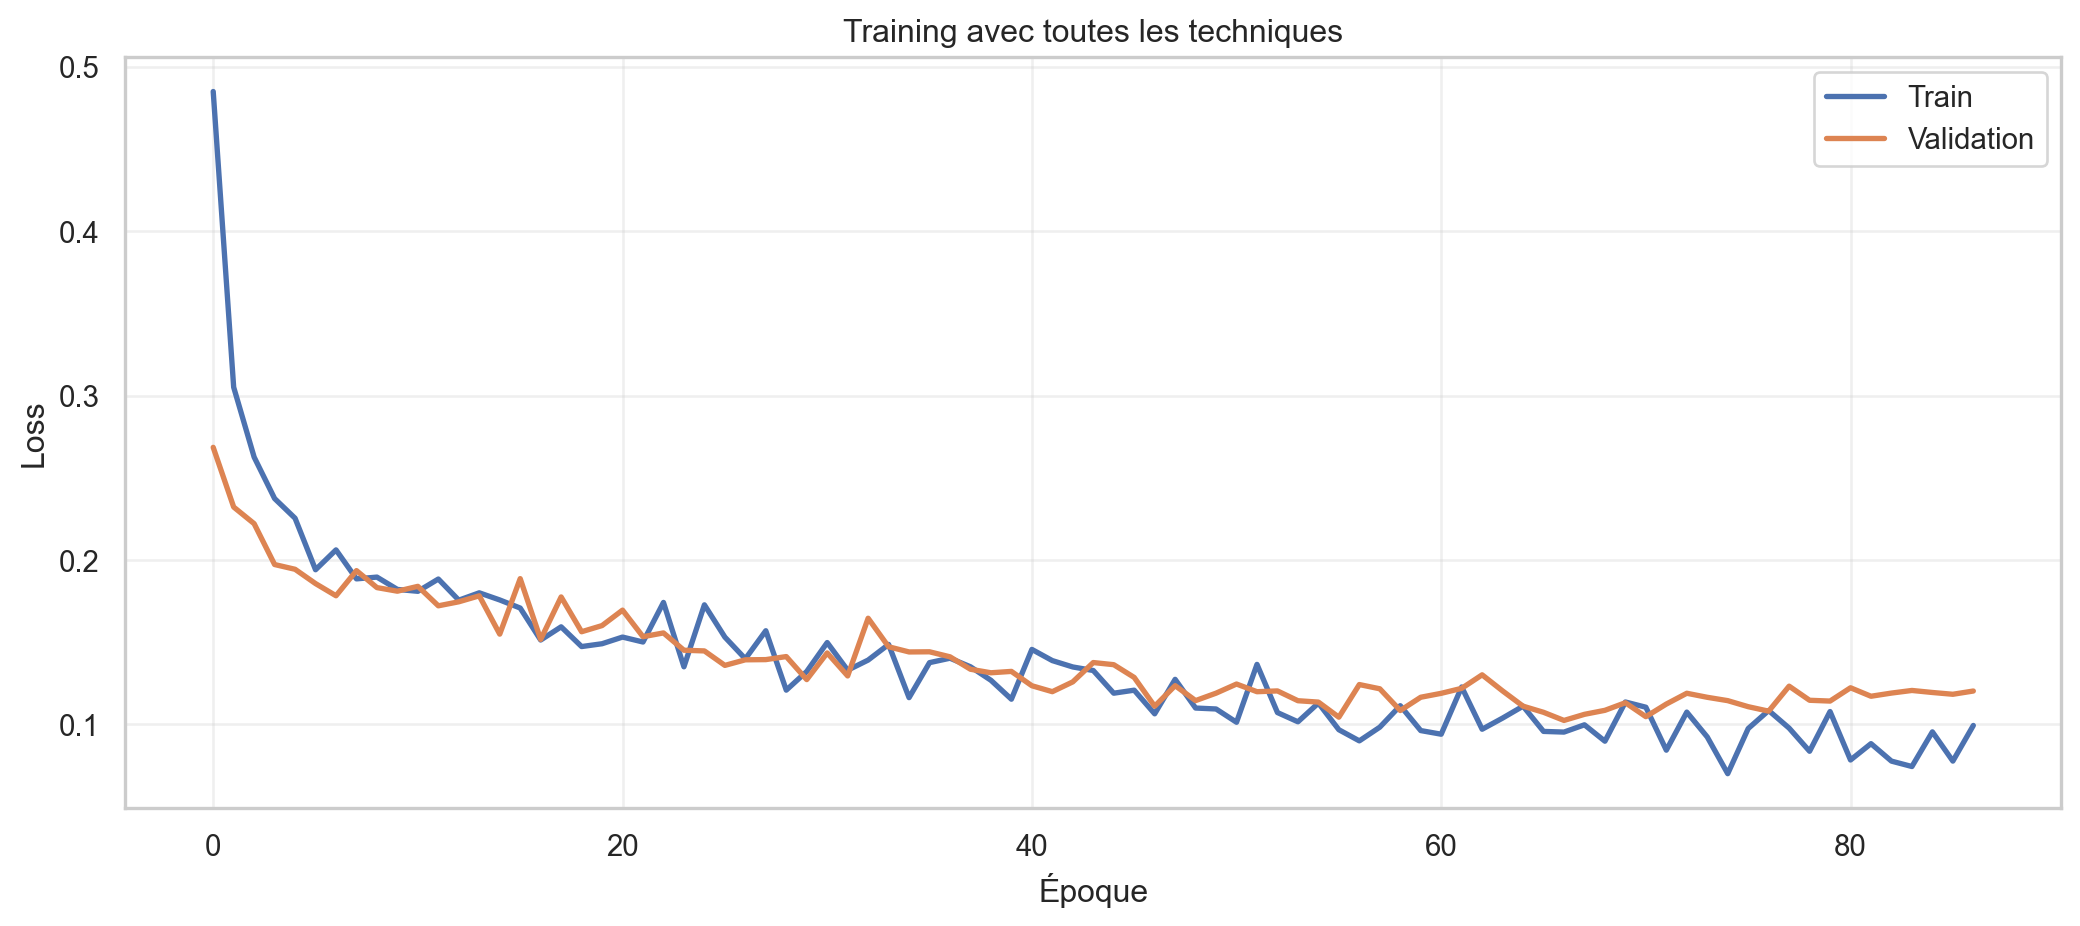


🎯 Accuracy test : 0.953


In [22]:
# Dataset
X, y = make_classification(n_samples=2000, n_features=15, n_informative=10,
                            n_classes=2, random_state=42)
X_tr, X_rest, y_tr, y_rest = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, stratify=y_rest)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_te = scaler.transform(X_te)

X_tr_t = torch.FloatTensor(X_tr); y_tr_t = torch.FloatTensor(y_tr).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val); y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
X_te_t = torch.FloatTensor(X_te); y_te_t = torch.FloatTensor(y_te).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

# Modèle complet
class ProMLP(nn.Module):
    def __init__(self, n_input, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(n_input, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 16)
        self.bn3 = nn.BatchNorm1d(16)
        self.fc4 = nn.Linear(16, 1)
        self.drop = nn.Dropout(dropout)
    
    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.drop(x)
        x = torch.relu(self.bn3(self.fc3(x)))
        x = self.drop(x)
        return self.fc4(x)

# Init He
def init_he(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)

torch.manual_seed(42)
modele = ProMLP(n_input=15)
modele.apply(init_he)

# Optimizer + scheduler
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(modele.parameters(), lr=0.01, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
early_stop = EarlyStopping(patience=20)

train_losses, val_losses = [], []
for epoch in range(100):
    # Train
    modele.train()
    epoch_losses = []
    for Xb, yb in train_loader:
        logits = modele(Xb)
        loss = loss_fn(logits, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_losses.append(loss.item())
    train_losses.append(np.mean(epoch_losses))
    scheduler.step()
    
    # Val
    modele.eval()
    with torch.no_grad():
        val_loss = loss_fn(modele(X_val_t), y_val_t).item()
    val_losses.append(val_loss)
    
    # Early stopping
    if early_stop.step(val_loss, modele):
        print(f"Early stop à l'époque {epoch}")
        break

# Restauration
early_stop.restore(modele)

# Affichage
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train_losses, linewidth=2, label="Train")
ax.plot(val_losses, linewidth=2, label="Validation")
ax.set_xlabel("Époque"); ax.set_ylabel("Loss")
ax.set_title("Training avec toutes les techniques")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Accuracy finale
modele.eval()
with torch.no_grad():
    acc_test = ((torch.sigmoid(modele(X_te_t)) >= 0.5).float() == y_te_t).float().mean().item()
print(f"\n🎯 Accuracy test : {acc_test:.3f}")